<a href="https://colab.research.google.com/github/Vale-Crz/Acne_Detector/blob/main/Acne_det_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!git clone https://github.com/Vale-Crz/Acne_Detector.git


Cloning into 'Acne_Detector'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 12 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 5.93 KiB | 5.93 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [7]:
!pip install roboflow ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.1 MB/s eta 0:00:00


In [8]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="G08g1IlWmTHJoEC4VhR2")
project = rf.workspace("valerias-workspace-la8ni").project("acne-kvuik-fqpto")
version = project.version(1)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...


In [9]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="G08g1IlWmTHJoEC4VhR2")
project = rf.workspace("valerias-workspace-la8ni").project("acne-kvuik-fqpto")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...


In [10]:
from ultralytics import YOLO
model = YOLO("yolo11s.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [11]:
data_path = "/content/Acne-1/data.yaml"
results = model.train(data=data_path,
                      epochs=15,
                      imgsz=640)

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Acne-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

In [14]:
# Cargamos el modelo ya entrenado
custom_model = YOLO("/content/runs/detect/train/weights/best.pt")

# Realizamos predicciones sobre algunas imágenes
res = custom_model("/content/Acne-1/train/images")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/3276 /content/Acne-1/train/images/ISIC_0024306_jpg.rf.daec8659809a9d4e6b0f5ceedcb9dfe1.jpg: 640x640 1 acne, 15.5ms
image 2/3276 /content/Acne-1/train/images/ISIC_0024308_jpg.rf.4c01a5abf3c175a57bc9fc258bd0808a.jpg: 640x640 1 acne, 15.5ms
image 3/3276 /content/Acne-1/train/images/ISIC_0024309_jpg.rf.76076d1ce9a3953c07a5f4f3fff3924f.jpg: 640x640 1 acne, 15.5ms
image 4/3276 /content/Acne-1/train/images/ISIC_0024310_jpg.rf.f0622d67eb2674e38e1bdc05cbd

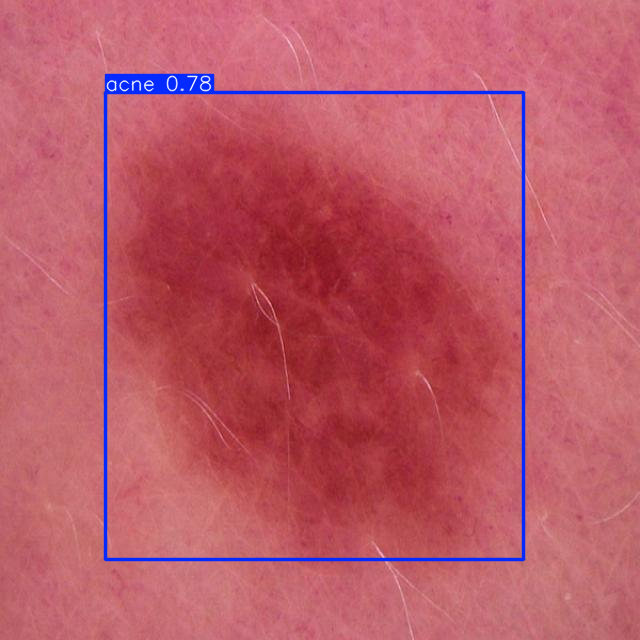

In [15]:
# Visualizamos los resultados de las detecciones
res[99].show()